In [ ]:
pip install fuzzywuzzy python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.7/162.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.4 MB/s eta 0:00:00


In [ ]:
from fuzzywuzzy import fuzz
from fuzzywuzzy import process

str1 = "I like Cricket"
str2 = "I like Football moreee"

simRatio = fuzz.ratio(str1, str2)
print(f'Similarity Ratio: {simRatio}')

partialSimRatio = fuzz.partial_ratio(str1, str2)
print(f'Partial Similarity Ratio: {partialSimRatio}')

tokenSortRatio = fuzz.tokenSortRatio(str1, str2)
print(f'Token Sort Ratio: {tokenSortRatio}')

choices = ["I like Basketball", "I like Football", "I like Cricket"]
bestMatch, score = process.extractOne(str1, choices)
print(f'Best Match: {bestMatch}, Score: {score}')

Similarity Ratio: 50
Partial Similarity Ratio: 57
Token Sort Ratio: 44
Best Match: I like Cricket, Score: 100


In [ ]:
2.2

2.2

In [ ]:
pip install thefuzz[speedup]


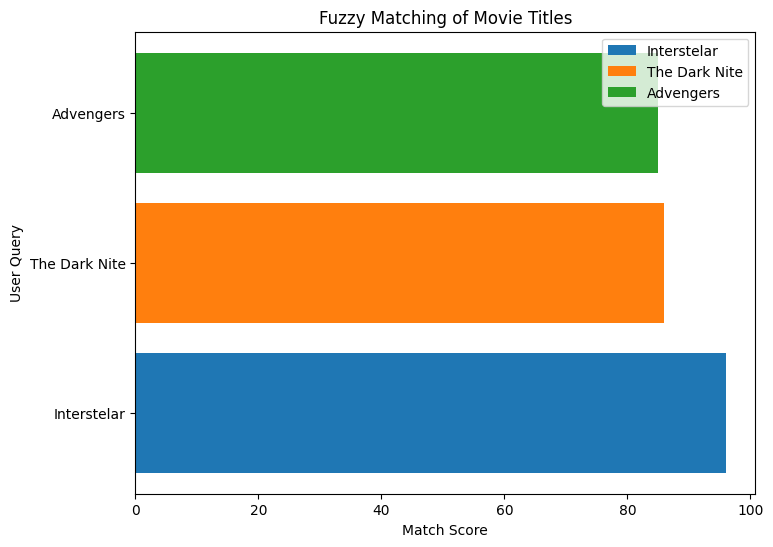

In [ ]:
from thefuzz import fuzz, process

movie_titles = [
    "The Matrix", "Inception", "Interstellar", "The Dark Knight", "Parasite", "Avengers: Endgame"
]

def suggest_movie(user_input, choices):
    matches = process.extract(user_input, choices, limit=3)
    return [(match, score) for match, score in matches if score > 75]

user_queries = ["Interstelar", "The Dark Nite", "Advengers"]
match_scores = {query: suggest_movie(query, movie_titles) for query in user_queries}

plt.figure(figsize=(8, 6))
for i, (query, matches) in enumerate(match_scores.items()):
    if matches:
        movies, scores = zip(*matches)
    else:
        movies, scores = [], []
    plt.barh([query] * len(movies), scores, label=query)

plt.xlabel("Match Score")
plt.ylabel("User Query")
plt.title("Fuzzy Matching of Movie Titles")
plt.legend()
plt.show()